In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.52G/6.52G [01:15<00:00, 92.4MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/fruits.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,BatchNormalization,Dropout
from keras import Sequential


In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/fruits-360_100x100/fruits-360/Training',
    labels = 'inferred',
    label_mode = 'int',
    image_size = (100,100),
    batch_size = 128
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/fruits-360_100x100/fruits-360/Test',
    labels = 'inferred',
    label_mode = 'int',
    image_size = (100,100),
    batch_size = 128
)


Found 137221 files belonging to 260 classes.
Found 45724 files belonging to 260 classes.


In [6]:

def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [7]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(100,100,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(260, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 260)            │        16,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,757,828 (6.71 MB)

 Trainable params: 1,757,380 (6.70 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(train_ds,epochs=50,validation_data=validation_ds)

Epoch 1/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 122s 104ms/step - accuracy: 0.0444 - loss: 4.7726 - val_accuracy: 0.2478 - val_loss: 3.4431
Epoch 2/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 60s 55ms/step - accuracy: 0.1663 - loss: 3.3688 - val_accuracy: 0.5045 - val_loss: 2.0433
Epoch 3/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.3105 - loss: 2.4946 - val_accuracy: 0.6444 - val_loss: 1.5386
Epoch 4/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 58s 54ms/step - accuracy: 0.4241 - loss: 1.9655 - val_accuracy: 0.7215 - val_loss: 1.2999
Epoch 5/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 59s 55ms/step - accuracy: 0.5010 - loss: 1.6613 - val_accuracy: 0.8007 - val_loss: 1.1654
Epoch 6/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 57s 53ms/step - accuracy: 0.5654 - loss: 1.4226 - val_accuracy: 0.8503 - val_loss: 1.1030
Epoch 7/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 58s 54ms/step - accuracy: 0.6110 - loss: 1.2660 - val_accuracy: 0.6716 - val_loss: 1.9799
Epoch 8/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.6491

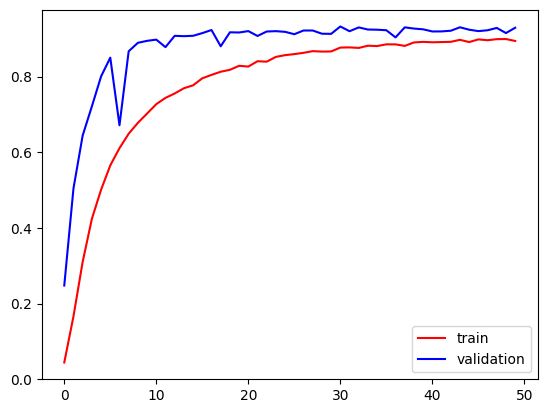

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

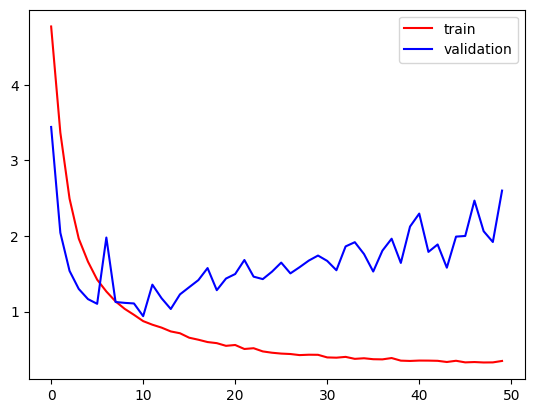

In [12]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()
